In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import scipy.ndimage as ndi

from src.data.paths import project_dir
from src.data.analysis import read_tiff_img, Circle, create_circular_mask
from src.data.detector import DetectorDataCollection, DetectorData, DetectorImage

In [2]:
colors = [(0, 1, 0), (1, 0, 0)]  # green -> red
cmap_name = 'custom_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors)

In [3]:
# local paths
base_path = project_dir / 'data' / 'raw'
#base_path = Path.home() / 'OneDrive - ifj.edu.pl' / 'Projects' / 'MB_foils'

base_path.exists()

True

In [4]:
proton_path = base_path / '2025-10-09'
proton_path.exists()

True

In [5]:
import pickle
with open(proton_path / 'proton_denoised_data.pkl', 'rb') as f:
    data = pickle.load(f)

In [6]:
left_image = data.data[1].raw.image
right_image = data.data[2].raw.image

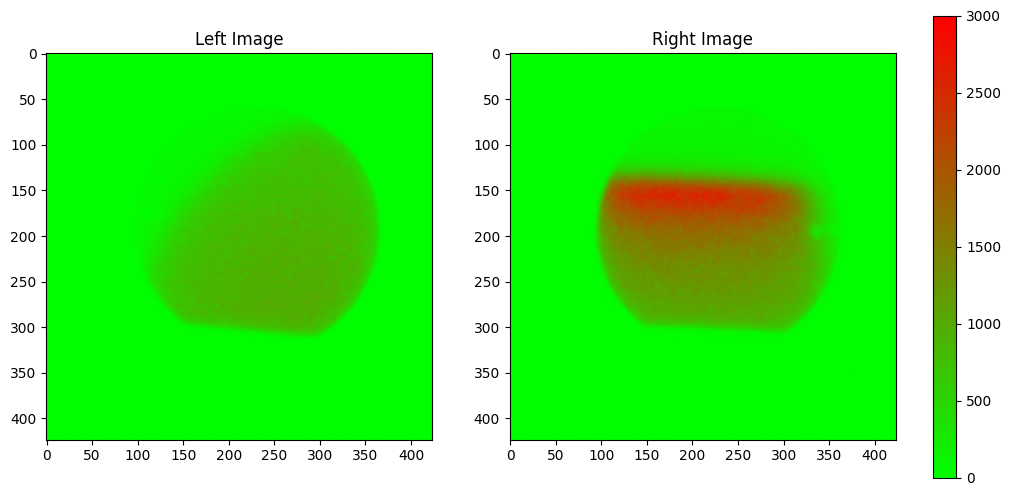

In [7]:
# plot left and right image side by side with vmax 3000 and custom cmap, add colorbar with colorscale
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
im1 = ax[0].imshow(left_image, cmap=custom_cmap, vmax=3000)
ax[0].set_title('Left Image')
im2 = ax[1].imshow(right_image, cmap=custom_cmap, vmax=3000)
ax[1].set_title('Right Image')
plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

In [9]:
# Data classes and computation functions for vertical sections
from dataclasses import dataclass
from typing import List, Optional, Tuple

@dataclass
class SectionResult:
    x: int
    profile: np.ndarray
    crossing_y: Optional[float]  # fractional y if found, else None

@dataclass
class ImageSections:
    image_name: str
    sections: List[SectionResult]


def compute_vertical_sections(img: np.ndarray, xs: List[int], stripe_width: int = 5, threshold: float = 400.0, search_from_bottom: bool = True) -> ImageSections:
    """Compute vertical profiles and interpolated crossings for given x positions.

    Returns an ImageSections object with per-section profiles and crossing points (fractional y).
    """
    import numpy as np
    h, w = img.shape
    half = stripe_width // 2

    def find_crossing_interpolated_bottom_to_top(profile, thr, y0, y1):
        sub = profile[y0:y1]
        idxs = np.where(sub >= thr)[0]
        if idxs.size == 0:
            return None
        last_idx = int(idxs.max())
        if last_idx == 0:
            return float(y0)
        prev = last_idx - 1
        v_low = float(sub[prev])
        v_high = float(sub[last_idx])
        if v_high == v_low:
            return float(y0 + last_idx)
        frac = (thr - v_low) / (v_high - v_low)
        return float(y0 + prev + frac)

    def find_crossing_interpolated_top_to_bottom(profile, thr, y0, y1):
        sub = profile[y0:y1]
        idxs = np.where(sub >= thr)[0]
        if idxs.size == 0:
            return None
        first_idx = int(idxs[0])
        if first_idx == 0:
            return float(y0)
        prev = first_idx - 1
        v_low = float(sub[prev])
        v_high = float(sub[first_idx])
        if v_high == v_low:
            return float(y0 + first_idx)
        frac = (thr - v_low) / (v_high - v_low)
        return float(y0 + prev + frac)

    finder = find_crossing_interpolated_bottom_to_top if search_from_bottom else find_crossing_interpolated_top_to_bottom

    sections: List[SectionResult] = []
    for x in xs:
        x0 = max(0, int(x - half))
        x1 = min(w, int(x + half + 1))
        section = img[:, x0:x1].astype(float)
        profile = np.nanmean(section, axis=1)
        y0_win, y1_win = 0, h
        crossing = finder(profile, threshold, y0_win, y1_win)
        sections.append(SectionResult(x=int(x), profile=profile, crossing_y=crossing))

    return ImageSections(image_name='image', sections=sections)


# Quick compute results for both images to make results available
left_sections = compute_vertical_sections(left_image, xs=[160,180,200,220,240,260], stripe_width=5, threshold=400, search_from_bottom=True)
right_sections = compute_vertical_sections(right_image, xs=[160,180,200,220,240,260], stripe_width=5, threshold=400, search_from_bottom=True)

print('Computed sections for left and right images')


Computed sections for left and right images


Left x=160: interpolated val=365.02, threshold=400
Right x=160: interpolated val=400.57, threshold=400
Left x=180: interpolated val=366.32, threshold=400
Right x=180: interpolated val=381.21, threshold=400
Left x=200: interpolated val=393.78, threshold=400
Right x=200: interpolated val=406.33, threshold=400
Left x=220: interpolated val=413.61, threshold=400
Right x=220: interpolated val=411.48, threshold=400
Left x=240: interpolated val=401.81, threshold=400
Right x=240: interpolated val=336.80, threshold=400
Left x=260: interpolated val=400.07, threshold=400
Right x=260: interpolated val=393.66, threshold=400


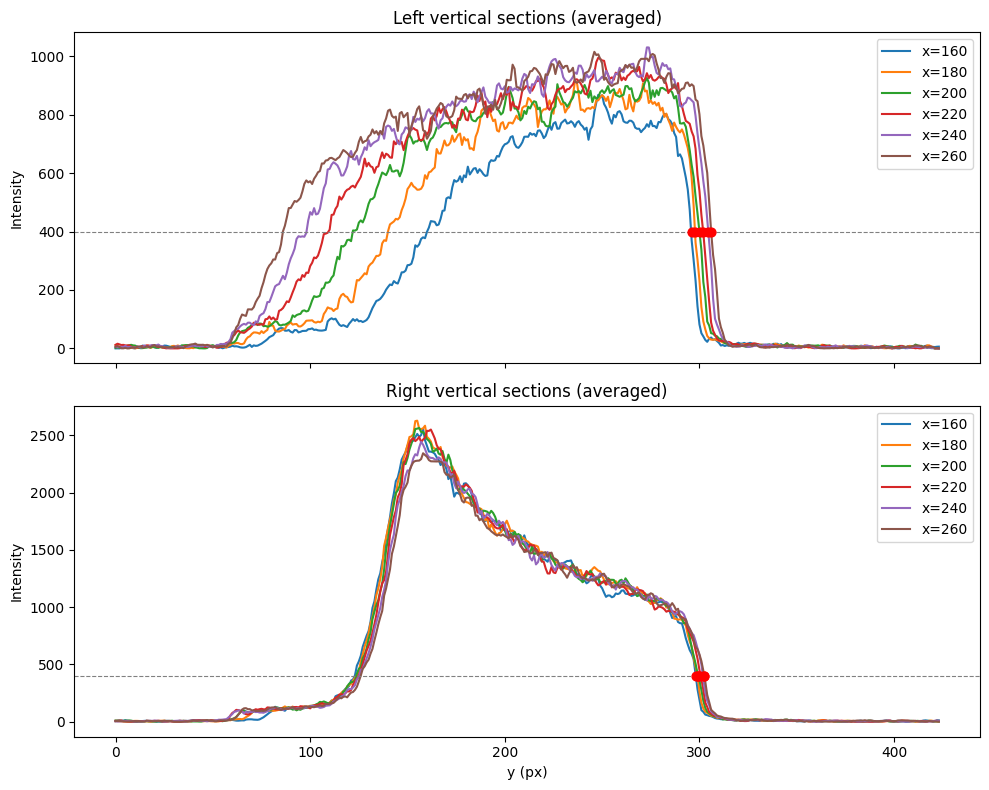

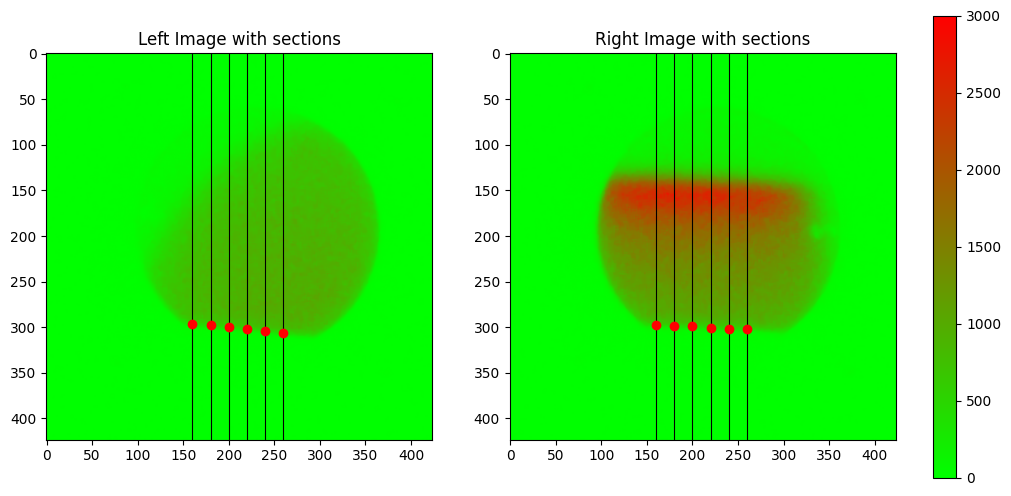

In [10]:
# Compute 5px-wide vertical sections at specified x positions and plot them
# Also overlay the vertical section lines on both images (thin black)

def plot_sections_and_overlay(left_img, right_img, xs=(160,180,200,220,240,260), stripe_width=5, threshold=400, search_from_bottom=True):
    import numpy as np
    import matplotlib.pyplot as plt

    h, w = left_img.shape
    half = stripe_width // 2

    # compute profiles for each x for both images
    profiles_left = []
    profiles_right = []
    crossings_left = []
    crossings_right = []

    def find_crossing_interpolated_top_to_bottom(profile, thr, y0, y1):
        sub = profile[y0:y1]
        idxs = np.where(sub >= thr)[0]
        if idxs.size == 0:
            return None
        first_idx = int(idxs[0])
        if first_idx == 0:
            return float(y0)
        prev = first_idx - 1
        v_low = float(sub[prev])
        v_high = float(sub[first_idx])
        if v_high == v_low:
            return float(y0 + first_idx)
        frac = (thr - v_low) / (v_high - v_low)
        return float(y0 + prev + frac)

    def find_crossing_interpolated_bottom_to_top(profile, thr, y0, y1):
        sub = profile[y0:y1]
        idxs = np.where(sub >= thr)[0]
        if idxs.size == 0:
            return None
        last_idx = int(idxs.max())
        if last_idx == 0:
            return float(y0)
        prev = last_idx - 1
        v_low = float(sub[prev])
        v_high = float(sub[last_idx])
        if v_high == v_low:
            return float(y0 + last_idx)
        frac = (thr - v_low) / (v_high - v_low)
        return float(y0 + prev + frac)

    finder = find_crossing_interpolated_bottom_to_top if search_from_bottom else find_crossing_interpolated_top_to_bottom

    for x in xs:
        x0 = max(0, int(x - half))
        x1 = min(w, int(x + half + 1))
        sec_left = left_img[:, x0:x1].astype(float)
        sec_right = right_img[:, x0:x1].astype(float)
        prof_left = np.nanmean(sec_left, axis=1)
        prof_right = np.nanmean(sec_right, axis=1)
        profiles_left.append(prof_left)
        profiles_right.append(prof_right)

        # search whole height (can be restricted by caller)
        y0_win, y1_win = 0, h
        y_l = finder(prof_left, threshold, y0_win, y1_win)
        y_r = finder(prof_right, threshold, y0_win, y1_win)
        crossings_left.append(y_l)
        crossings_right.append(y_r)

    # Plot sections in separate figure
    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for i, x in enumerate(xs):
        prof_l = profiles_left[i]
        prof_r = profiles_right[i]
        axs[0].plot(np.arange(h), prof_l, label=f'x={x}')
        axs[1].plot(np.arange(h), prof_r, label=f'x={x}')
        if crossings_left[i] is not None:
            y_idx = crossings_left[i]
            # compute interpolated intensity at y_idx to verify it's the threshold
            y_low = int(np.floor(y_idx))
            y_high = min(int(np.ceil(y_idx)), len(prof_l)-1)
            if y_low == y_high:
                val = prof_l[y_low]
            else:
                t = y_idx - y_low
                val = (1-t)*prof_l[y_low] + t*prof_l[y_high]
            # plot marker at exact threshold height to show crossing level
            axs[0].scatter(y_idx, threshold, s=40, color='red', zorder=5)
            # optionally print small difference if debug
            if abs(val - threshold) > 1e-3:
                print(f'Left x={x}: interpolated val={val:.2f}, threshold={threshold}')
        if crossings_right[i] is not None:
            y_idx = crossings_right[i]
            y_low = int(np.floor(y_idx))
            y_high = min(int(np.ceil(y_idx)), len(prof_r)-1)
            if y_low == y_high:
                valr = prof_r[y_low]
            else:
                t = y_idx - y_low
                valr = (1-t)*prof_r[y_low] + t*prof_r[y_high]
            axs[1].scatter(y_idx, threshold, s=40, color='red', zorder=5)
            if abs(valr - threshold) > 1e-3:
                print(f'Right x={x}: interpolated val={valr:.2f}, threshold={threshold}')

    # draw horizontal threshold lines
    axs[0].axhline(threshold, color='gray', linestyle='--', linewidth=0.8)
    axs[1].axhline(threshold, color='gray', linestyle='--', linewidth=0.8)

    axs[0].set_title('Left vertical sections (averaged)')
    axs[0].set_ylabel('Intensity')
    axs[0].legend()
    axs[1].set_title('Right vertical sections (averaged)')
    axs[1].set_ylabel('Intensity')
    axs[1].set_xlabel('y (px)')
    axs[1].legend()
    plt.tight_layout()
    plt.show()

    # Overlay vertical thin black lines on the images at each x
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    im0 = ax[0].imshow(left_img, cmap=custom_cmap, vmax=3000)
    ax[0].set_title('Left Image with sections')
    im1 = ax[1].imshow(right_img, cmap=custom_cmap, vmax=3000)
    ax[1].set_title('Right Image with sections')

    for x in xs:
        ax[0].plot([x, x], [0, h-1], color='black', linewidth=0.8)
        ax[1].plot([x, x], [0, h-1], color='black', linewidth=0.8)

    # also mark crossing points on images (interpolated y may be fractional)
    for i, x in enumerate(xs):
        cl = crossings_left[i]
        if cl is not None:
            ax[0].plot(x, cl, 'ro', markersize=6)
        cr = crossings_right[i]
        if cr is not None:
            ax[1].plot(x, cr, 'ro', markersize=6)

    plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

# Run on left_image and right_image (ensure they are defined)
plot_sections_and_overlay(left_image, right_image, xs=(160,180,200,220,240,260), stripe_width=5, threshold=400, search_from_bottom=True)
